In [2]:
import numpy as np
from gyrointerp import gyro_age_posterior
import matplotlib.pyplot as plt

[I 250918 11:23:10 utils:161] NumExpr defaulting to 16 threads.


In [3]:
# units: days
Prot, Prot_err = 20., 1.

In [4]:
# units: kelvin
Teff, Teff_err = 5322, 100

In [5]:
# uniformly spaced grid between 0 and 2600 megayears
age_grid = np.linspace(0, 4000, 500)

In [6]:
# calculate the age posterior at each age in `age_grid`
age_posterior = gyro_age_posterior(
    Prot, Teff,
    Prot_err=Prot_err, Teff_err=Teff_err,
    age_grid=age_grid
)

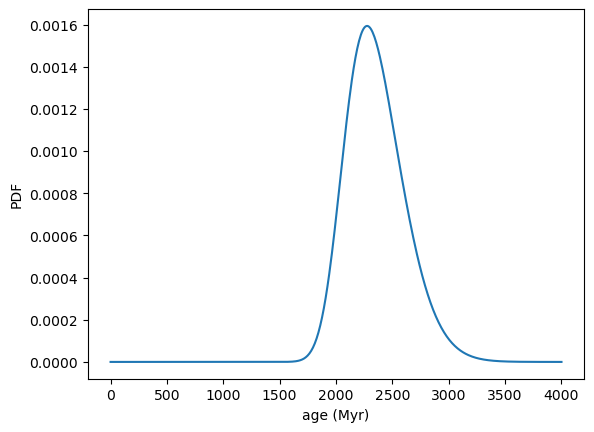

In [18]:
plt.ylabel("PDF")
plt.xlabel("age (Myr)")
plt.plot(age_grid, age_posterior)
plt.savefig("gyrointerp_posterior.png", dpi=200, bbox_inches="tight")

In [13]:
def mu_and_sigma(x, y):
    y_norm = y / np.trapz(y, x)

    # Mean
    mean = np.trapz(x * y_norm, x)

    # Variance
    variance = np.trapz((x - mean)**2 * y_norm, x)

    return mean, np.sqrt(variance)

In [15]:
mu, sigma = mu_and_sigma(age_grid, age_posterior)

In [17]:
print(f"{mu/1e3:.2f} +/- {sigma/1e3:.2f} Gyr")

2.35 +/- 0.26 Gyr
